# Загрузка библиотек


In [155]:
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import seaborn as sns
import joblib

# Загрузка датасетов

In [156]:
features = pd.read_csv("Features data set.csv")
stores = pd.read_csv("stores data-set.csv")
sales = pd.read_csv("sales data-set.csv")

In [157]:
print(sales.dtypes)
print(features.dtypes)
print(stores.dtypes)

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object
Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object
Store     int64
Type     object
Size      int64
dtype: object


Дату из obj надо перевести в dt
Да и в целом по всем параметрам и привести их в норм. форматы

In [158]:
features["Store"]=features["Store"].astype("category")
features["Date"]=pd.to_datetime(features["Date"],dayfirst=True)
features["IsHoliday"]=features["IsHoliday"].map({True:1,False:0}).astype("category")
features["Week"]=features["Date"].dt.isocalendar().week
features["Year"]=features["Date"].dt.isocalendar().year
for i in range(1,6):
  if i==1:
    features["MarkDowns"]=features["MarkDown%s" % i]
  else:
    features["MarkDowns"]=features["MarkDowns"]+features["MarkDown%s" % i]
featsfloatcols=["Temperature","Fuel_Price","CPI", "Unemployment", "MarkDowns"]+["MarkDown%s" % i for i in range(1,6)]
features[featsfloatcols]=features[featsfloatcols].astype("float64")
features["Weight"]=features["IsHoliday"].map({1:5,0:1}).astype("int64")
stores["Store"]=stores["Store"].astype("category")
stores["Type"]=stores["Type"].astype("category")

sales["Store"]=sales["Store"].astype("category")
sales["Dept"]=sales["Dept"].astype("category")
sales["IsHoliday"]=sales["IsHoliday"].map({True:1,False:0}).astype("category")
sales["Date"]=pd.to_datetime(sales["Date"],dayfirst=True)

In [159]:
# итого:

print(sales.dtypes)
print(features.dtypes)
print(stores.dtypes)

Store                 category
Dept                  category
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday             category
dtype: object
Store                 category
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday             category
Week                    UInt32
Year                    UInt32
MarkDowns              float64
Weight                   int64
dtype: object
Store    category
Type     category
Size        int64
dtype: object


Смотрим состав датасетов

In [160]:
sales

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,0
1,1,1,2010-02-12,46039.49,1
2,1,1,2010-02-19,41595.55,0
3,1,1,2010-02-26,19403.54,0
4,1,1,2010-03-05,21827.90,0
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,0
421566,45,98,2012-10-05,628.10,0
421567,45,98,2012-10-12,1061.02,0
421568,45,98,2012-10-19,760.01,0


In [161]:
features

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week,Year,MarkDowns,Weight
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,1,6,2010,NaN,5
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,0,7,2010,NaN,1
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,0,8,2010,NaN,1
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,0,9,2010,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,0,26,2013,11439.98,1
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,0,27,2013,19254.20,1
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,0,28,2013,8598.17,1
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,0,29,2013,5635.21,1


In [162]:
stores

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [163]:
# размерность

print(sales.shape, features.shape, stores.shape)

(421570, 5) (8190, 16) (45, 3)


In [164]:
# заготовка для Марселя для предсказаний
# используем на сл. этапе проекта

futuresales=sales[["Store","Dept"]].drop_duplicates()
futuresales["Weekly_Sales"]=np.nan
futuredates=features[features["Date"]>sales["Date"].max()][["Store","Date","IsHoliday"]]
futuresales=futuresales.merge(futuredates,on="Store", how="outer")
salesV2=pd.concat([sales,futuresales])

In [165]:
# объединяем датасеты

tmp = pd.merge(features, sales, on=['Store', 'Date'], how='inner', suffixes=('', '_sales'))
data = pd.merge(tmp, stores, on='Store', how='inner')
data = data.drop(columns=['IsHoliday_sales'])  # `features` contains more information than `sales`, so drop the `IsHoliday` column from `sales`
data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y')
data.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week,Year,MarkDowns,Weight,Dept,Weekly_Sales,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,1,24924.50,A,151315
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,2,50605.27,A,151315
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,3,13740.12,A,151315
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,4,39954.04,A,151315
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,5,32229.38,A,151315


In [166]:
# смотрим что получилось в конечном датасете

data.describe()

,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Year,MarkDowns,Weight,Weekly_Sales,Size
count,421570,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.0,421570.0,97056.000000,421570.000000,421570.000000,421570.000000
mean,2011-06-18 08:30:31.963375360,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,25.826762,2010.968591,23688.175817,1.281434,15981.258123,136727.915739
min,2010-02-05 00:00:00,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,1.0,2010.0,567.350000,1.000000,-4988.940000,34875.000000
25%,2010-10-08 00:00:00,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,14.0,2010.0,9944.170000,1.000000,2079.650000,93638.000000
50%,2011-06-17 00:00:00,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,26.0,2011.0,16718.320000,1.000000,7612.030000,140167.000000
75%,2012-02-24 00:00:00,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,38.0,2012.0,28378.110000,1.000000,20205.852500,202505.000000
max,2012-10-26 00:00:00,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,52.0,2012.0,160510.610000,5.000000,693099.360000,219622.000000
std,NaN,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,14.151887,0.796876,21717.452137,1.023002,22711.183519,60980.583328


In [167]:
print(data.shape)

(421570, 20)


Подробнее изучим каждый столбец с данными.  

Столбцы с разметкой Markdown содержат обезличенные данные о скидках.
Мы выяснили, что только в этих столбцах есть пустые значения. Можно заполнить эти значения нулями, но это не лучшая идея, поскольку пропущенных значений слишком много. Также можно исключить эти пять столбцов из наших задач.

In [168]:
data.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479
MarkDown4,286603
MarkDown5,270138
CPI,0


Смотрим распределение NaN значений в Markdown колонках по отношению ко времени

In [169]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
data['Month'] = data['Date'].dt.to_period('M').dt.to_timestamp()

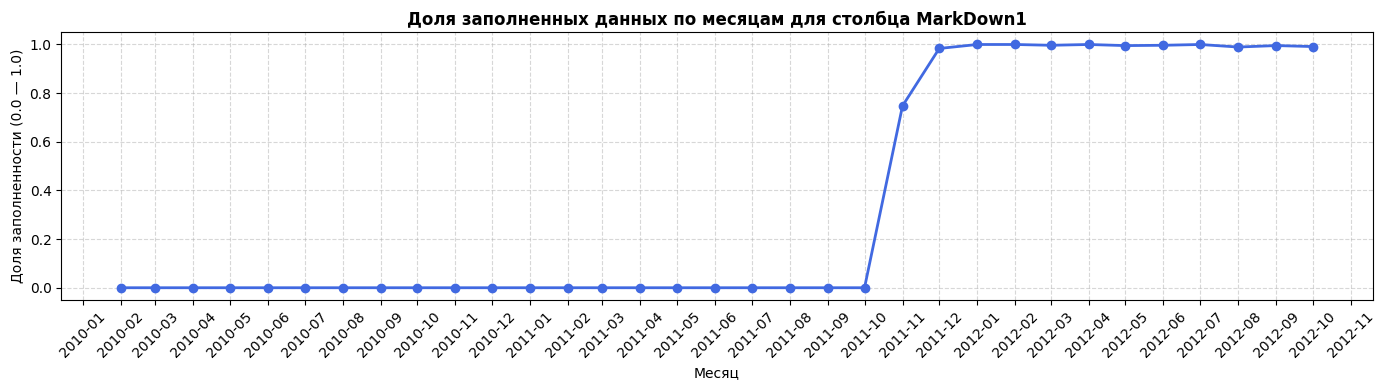

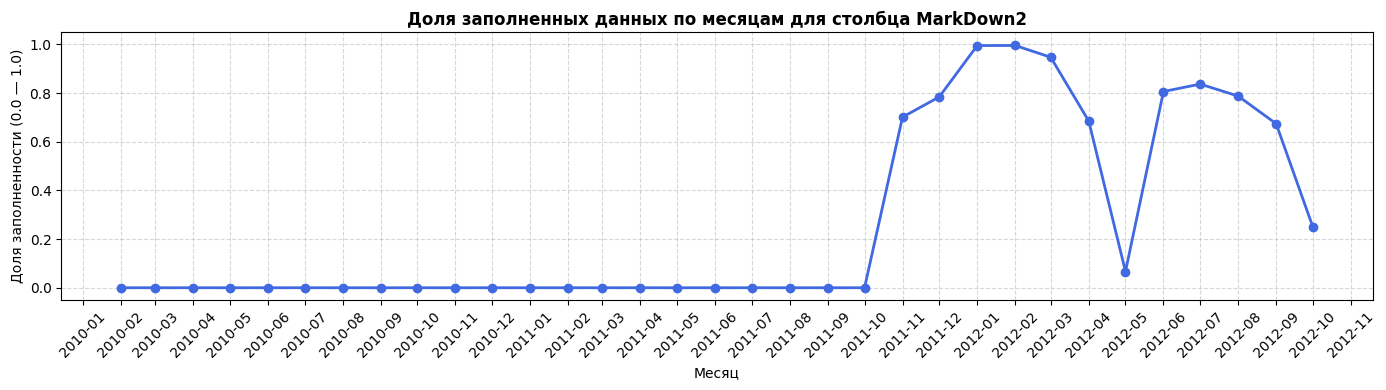

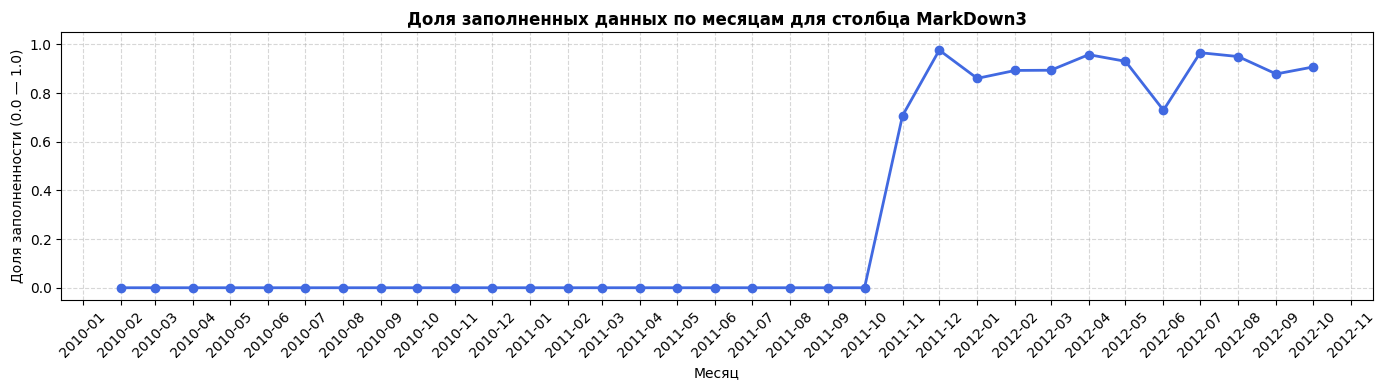

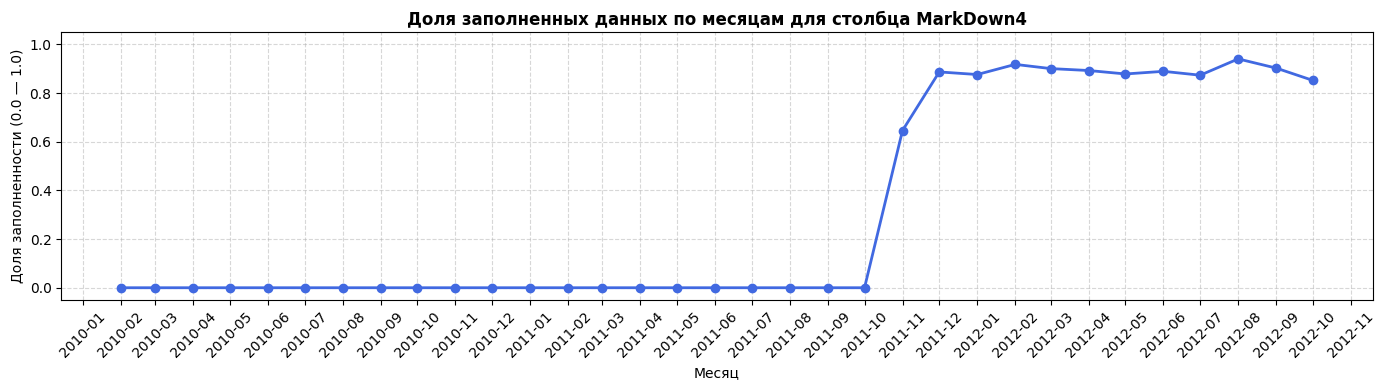

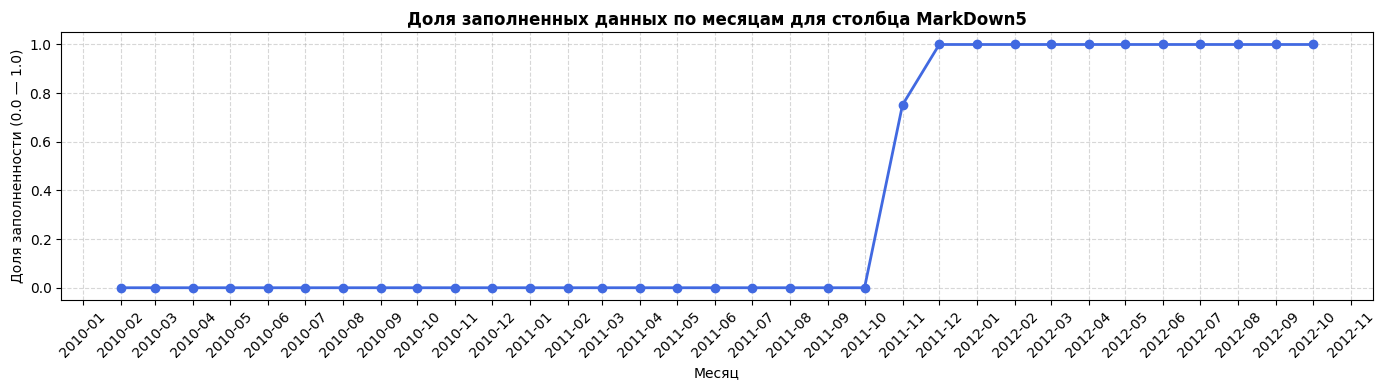

In [170]:
for col in markdown_cols:
    plt.figure(figsize=(14, 4))

    monthly_agg = data.groupby('Month')[col].agg(
        Total='size',
        Filled=lambda x: x.notna().sum()
    ).reset_index()

    monthly_agg['Ratio'] = monthly_agg['Filled'] / monthly_agg['Total']

    plt.plot(monthly_agg['Month'], monthly_agg['Ratio'], marker='o', linestyle='-', color='royalblue', linewidth=2)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)

    plt.title(f'Доля заполненных данных по месяцам для столбца {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Месяц', fontsize=10)
    plt.ylabel('Доля заполненности (0.0 — 1.0)', fontsize=10)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Исторические данные о продажах охватывают период с 5 февраля 2010 года по 26 октября 2012 года,
то есть 143 недели, и все данные собраны по пятницам.

In [171]:
tmp = data[['Date']].drop_duplicates()
max_date = tmp.max().iloc[0]
min_date = tmp.min().iloc[0]
cnt = (max_date - min_date).days // 7 + 1

print('max date: %s, min date: %s\n'
      'number of weeks between max date and min date: %d\n'
      'number of unique dates in data: %d\n'
      'is the dates all Friday: %s' %
      (max_date.strftime('%Y-%m-%d'), min_date.strftime('%Y-%m-%d'), cnt, tmp.shape[0], (tmp['Date'].dt.day_name() == 'Friday').all()))

max date: 2012-10-26, min date: 2010-02-05
number of weeks between max date and min date: 143
number of unique dates in data: 143
is the dates all Friday: True


Температура, цена на топливо, индекс потребительских цен, уровень безработицы,
недельные продажи — это непрерывные переменные, которые меняются с течением времени,
поэтому мы можем построить линейные графики, чтобы увидеть их динамику.


На графиках ниже по оси Y отложены средние значения данных на указанную дату.
Мы видим, что периодичность изменения температуры и недельных продаж очевидна,
а индекс потребительских цен растет, в то время как уровень безработицы снижается.

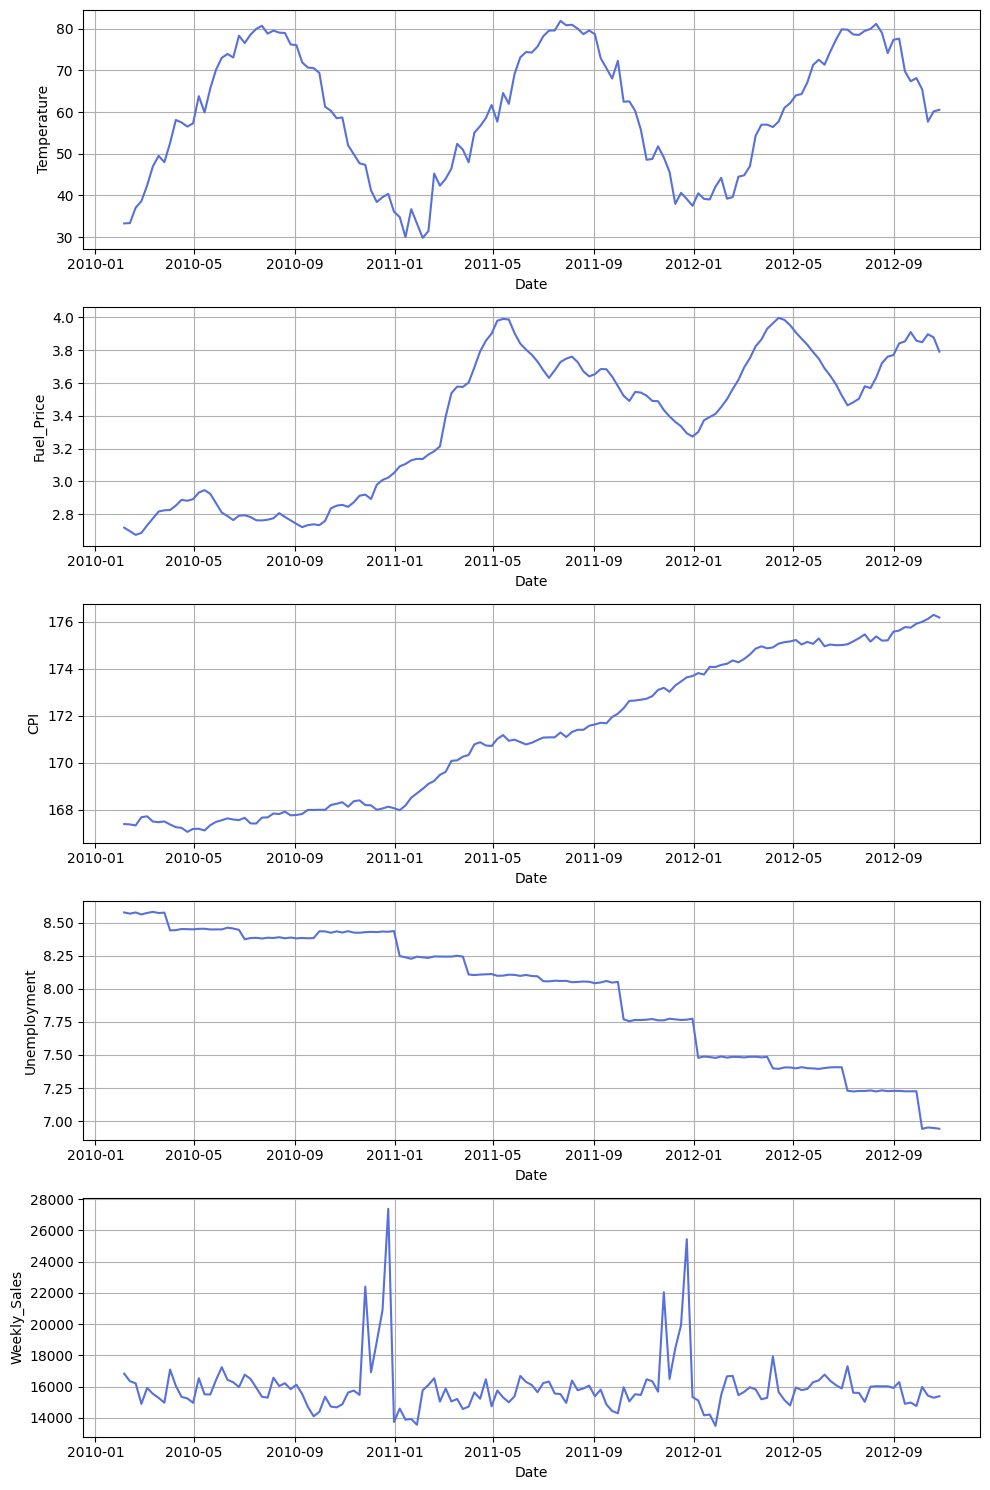

In [172]:
columns = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Weekly_Sales']
tmp = data.groupby(['Date'])[columns].mean().reset_index()

fig, axes = plt.subplots(nrows=len(columns), ncols=1, figsize=(10, 15))
for ax, column in zip(axes, columns):
    ax.plot(tmp['Date'], tmp[column], color=sns.color_palette('hls', 8)[5])
    ax.set_xlabel('Date')
    ax.set_ylabel('%s' % column)
    ax.grid()
plt.tight_layout()
plt.show()

Помимо этих пяти непрерывных данных, рассмотрим взаимосвязь между дискретными данными.

Смотрим принадлежность магазинов к департаментам

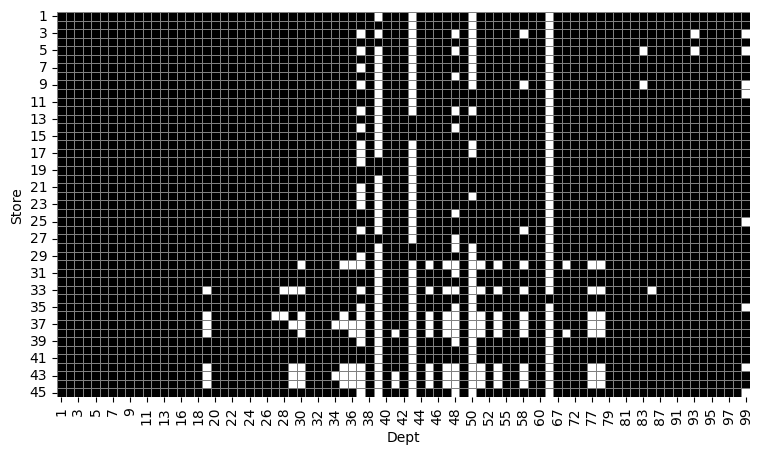

In [173]:
tmp = data[['Store', 'Dept']].drop_duplicates()
tmp = tmp.pivot_table(index='Store', columns='Dept', aggfunc='size', fill_value=0)
plt.figure(figsize=(10, 5))
sns.heatmap(tmp, cmap='binary', cbar=False, linewidths=.5, linecolor='gray', square=True)
plt.show()

Необходимо определить недельный объем продаж магазина как сумму еженедельных продаж по отделам этого магазина.

Мы проанализируем средний недельный объем продаж каждого магазина за этот период, а также его взаимосвязь с типом магазина.

Из столбчатой диаграммы видно, что общий объем продаж в каждом магазине сильно различается, при этом в магазинах типа C продажи относительно ниже. Кроме того, к типу C относятся только шесть магазинов, остальные относятся к типу A или B.

In [174]:
from matplotlib.patches import Patch

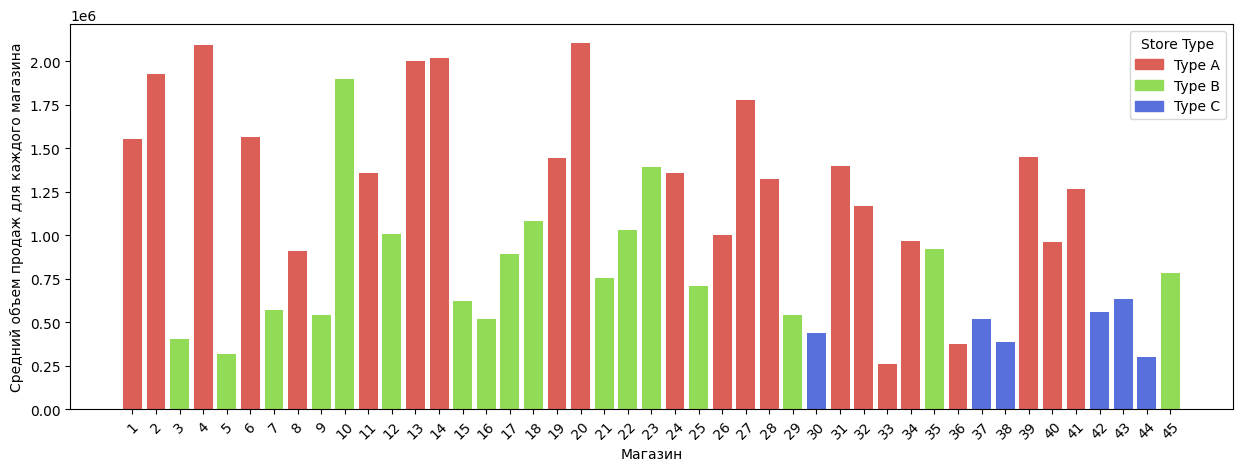

In [175]:
tmp = data.groupby(['Store', 'Date'])['Weekly_Sales'].sum().reset_index()  # все
tmp = tmp.groupby('Store')['Weekly_Sales'].mean().reset_index()  # среднее
tmp = tmp.merge(data[['Store', 'Type']].drop_duplicates(), on='Store', how='left')
plt.figure(figsize=(15, 5))
plt.bar(tmp['Store'], tmp['Weekly_Sales'],
        color=[sns.color_palette('hls', 8)[i] for i in tmp['Type'].replace({'A': 0, 'B': 2, 'C': 5})])
plt.legend(handles=[Patch(color=sns.color_palette('hls', 8)[i],
           label=f'Type {type_}') for type_,
           i in zip(tmp['Type'].unique(), [0, 2, 5])],
           title='Store Type'
           )
plt.xticks(rotation=45)
plt.xticks(tmp['Store'])
plt.xlabel('Магазин')
plt.ylabel('Средний объем продаж для каждого магазина')
plt.show()

Нам известно, что в некоторых магазинах нет определенных отделов. Можно предположить, что наличие прибыльного отдела может увеличить общий объем продаж в магазине. Ниже приведены средние показатели продаж по отделам. Мы видим, что средние показатели продаж по некоторым отделам довольно высоки, а значит, наличие таких отделов в магазине может привести к увеличению продаж.

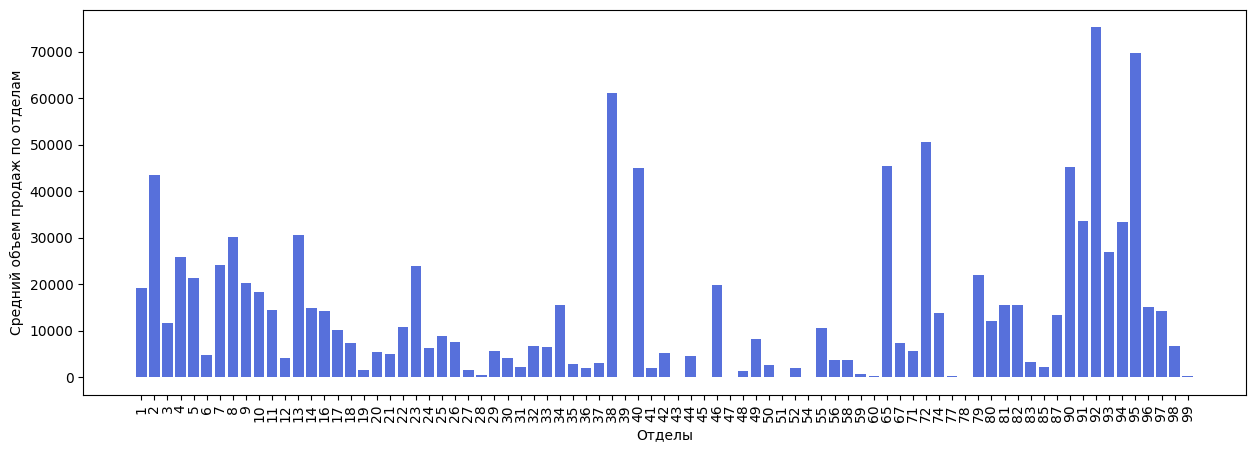

In [176]:
tmp = data.groupby('Dept')['Weekly_Sales'].mean().reset_index()
plt.figure(figsize=(15, 5))
plt.bar(tmp['Dept'].astype(str), tmp['Weekly_Sales'], color=sns.color_palette('hls', 8)[5])
plt.xticks(rotation=90)
plt.xticks(tmp['Dept'].astype(str))
plt.xlabel('Отделы')
plt.ylabel('Средний объем продаж по отделам')
plt.show()

In [177]:
# dept_store_sales = data.groupby(['Store', 'Dept'])['Weekly_Sales'].mean().reset_index()

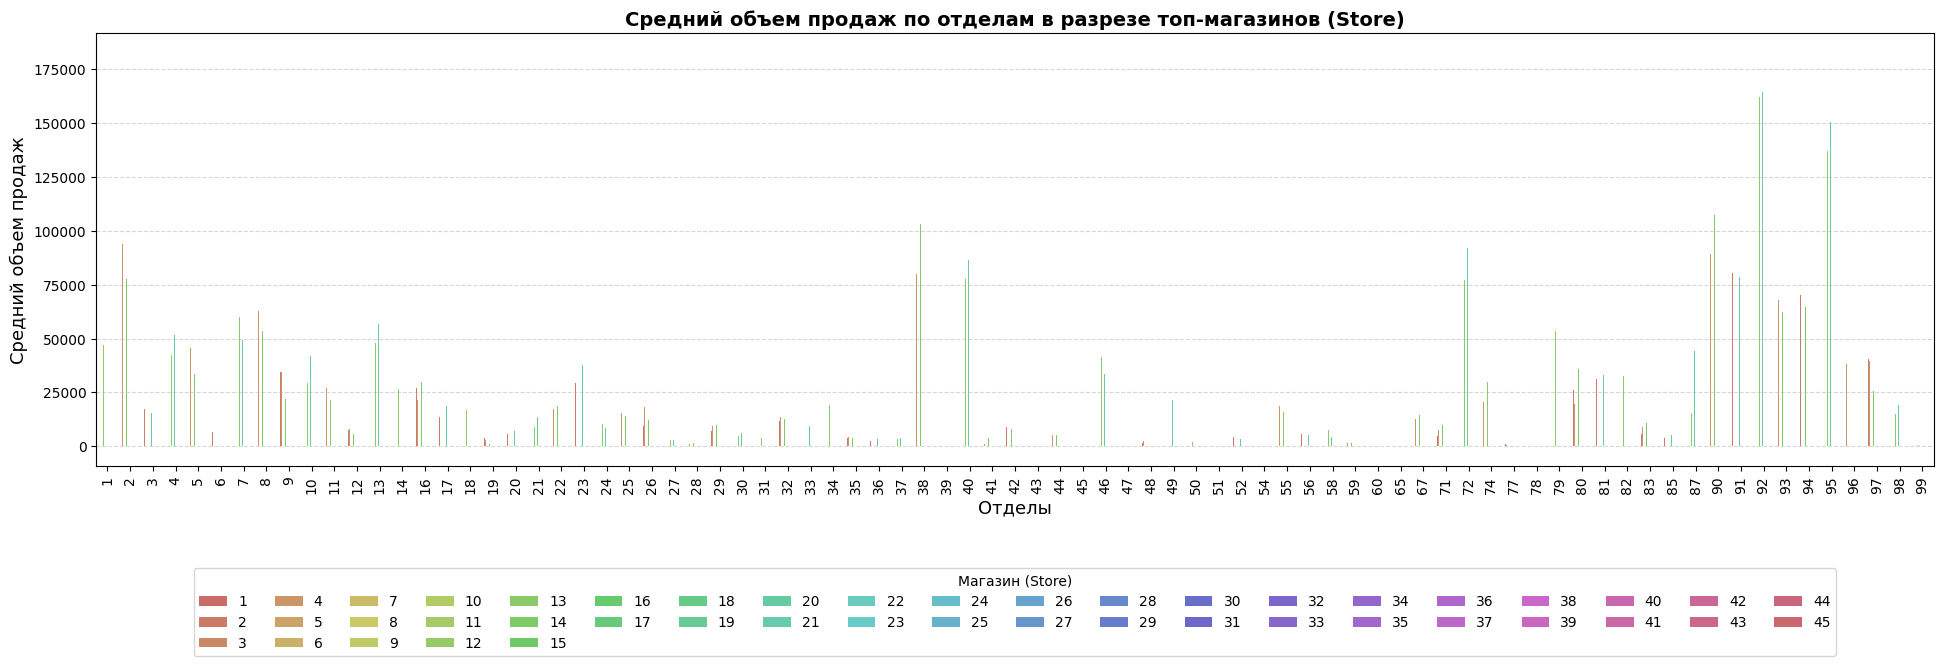

In [178]:
top_stores = data.groupby('Store')['Weekly_Sales'].mean().nlargest(5).index
filtered_data = data[data['Store'].isin(top_stores)]

tmp = filtered_data.groupby(['Dept', 'Store'])['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(20, 7))

sns.barplot(
    data=tmp,
    x='Dept',
    y='Weekly_Sales',
    hue='Store',
    palette='hls'
)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Отделы', fontsize=13)
plt.ylabel('Средний объем продаж', fontsize=13)
plt.title('Средний объем продаж по отделам в разрезе топ-магазинов (Store)', fontsize=14, fontweight='bold')
plt.legend(
    title='Магазин (Store)',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=20,
    frameon=True
)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

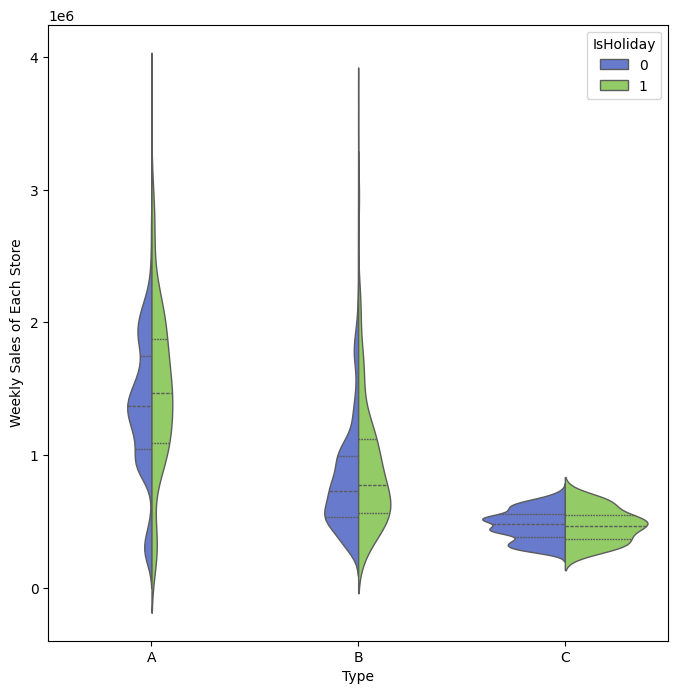

In [179]:
tmp = data.groupby(['Store', 'Date'])['Weekly_Sales'].sum().reset_index()  # weekly total sales of stores
tmp = tmp.merge(data[['Store', 'Type']].drop_duplicates(), on='Store', how='left')
tmp = tmp.merge(data[['Date', 'IsHoliday']].drop_duplicates(), on='Date', how='left')
plt.figure(figsize=(8, 8))
sns.violinplot(x='Type', y='Weekly_Sales', hue='IsHoliday', data=tmp,
               inner='quart', split=True, linewidth=1,
               palette={True: sns.color_palette('hls', 8)[2], False: sns.color_palette('hls', 8)[5]})
plt.ylabel('Weekly Sales of Each Store')
plt.show()

На рисунке видно, как общий объем продаж в магазинах соотносится со столбцами IsHoliday и Type. Мы видим, что в праздничные дни для всех трех типов магазинов характерен более длинный «хвост» распределения с более высокими продажами, а средний объем продаж в праздничные дни немного выше, чем в обычные.

# Гипотеза 1: Чем больше магазин по площади - тем он устойчивее к влияниям внешних факторов. Праздники, сезонность, погоды уровня безработицы, индексу потреб.цен и пр.

Судя по всему, магазины тут измеряются не в квадратных метрах. Иначе это слишком огромные магазины. если это квадратные футы, то это уже вероятнее.
min 34875
max 219622

в датасете уже есть некоторое разделение магазинов. нужно посмотреть, по размерам ли оно. Варианты возможны разные, например, разделение по регионам или по размеру прибыли.

In [180]:
checking_1 = ['Size']
stores.groupby(['Type'])[checking_1].agg(['mean', 'max', 'min']).round(2)

Size               
           mean     max    min
Type                          
A     177247.73  219622  39690
B     101190.71  140167  34875
C      40541.67   42988  39690

In [181]:
import scipy.stats as stats

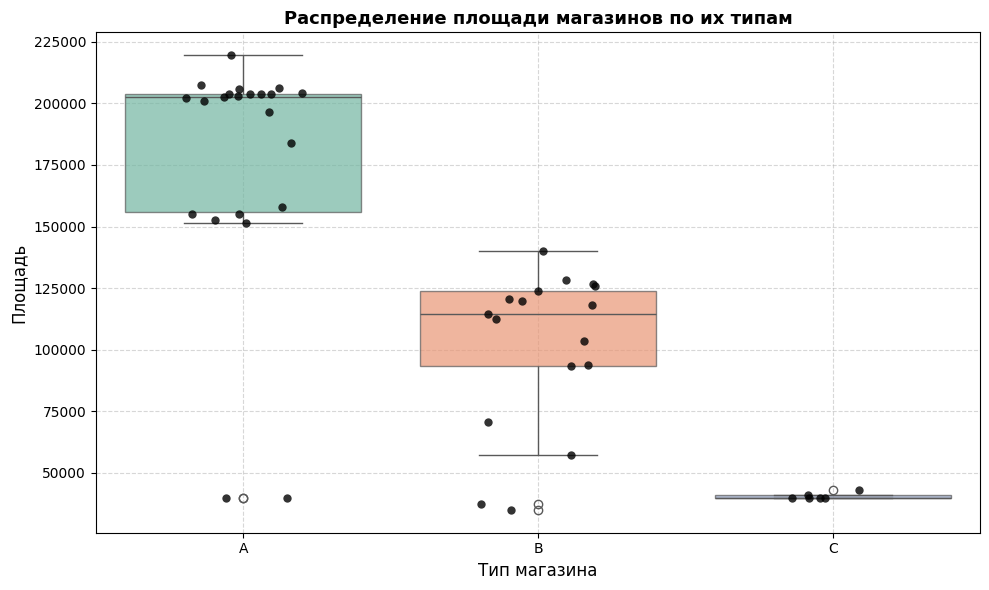

In [182]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=stores,
    x='Type',
    y='Size',
    palette='Set2',
    boxprops=dict(alpha=0.7)
)
sns.stripplot(
    data=stores,
    x='Type',
    y='Size',
    color='black',
    alpha=0.8,
    jitter=0.2,
    size=6
)

plt.title('Распределение площади магазинов по их типам', fontsize=13, fontweight='bold')
plt.xlabel('Тип магазина', fontsize=12)
plt.ylabel('Площадь', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# вывод - типы A B C скорее всего не про размерность, они определяют категории, которые мы не можем понять
# в том числе подтверждается выбросами у типа А и B

Понятно, не по размеру. Может, быть по выручке

In [183]:
result_1 = pd.merge(
   sales,
   stores,
   on= 'Store',
   how= 'left'
)

In [184]:
result_1.sample(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
291051,30,67,2011-06-24,2447.42,0,C,42988
264551,27,74,2011-04-01,26599.95,0,A,204184
57580,6,87,2011-01-21,30670.14,0,A,202505
306345,32,19,2011-11-18,1616.32,0,A,203007
243519,25,54,2011-05-06,15.88,0,B,128107
59596,7,5,2010-07-23,10466.86,0,B,70713
183549,19,52,2012-06-01,1620.54,0,A,203819
373159,40,17,2011-03-25,6198.27,0,A,155083
9966,1,97,2010-12-17,35614.14,0,A,151315
89690,10,17,2010-07-02,24416.82,0,B,126512


In [185]:
checking_2 = ['Weekly_Sales']
data.groupby(['Type'])[checking_2].agg(['mean', 'max', 'min']).round(2)

Weekly_Sales                    
             mean        max      min
Type                                 
A        20099.57  474330.10 -4988.94
B        12237.08  693099.36 -3924.00
C         9519.53  112152.35  -379.00

Видимо Type присвоен по регионам, потому как по продажам или по размеру нет очевидной закономерности.

Воспользуемся визуальными методами. Построим гистограмму по значениям столбца size

Text(0, 0.5, 'Qty')

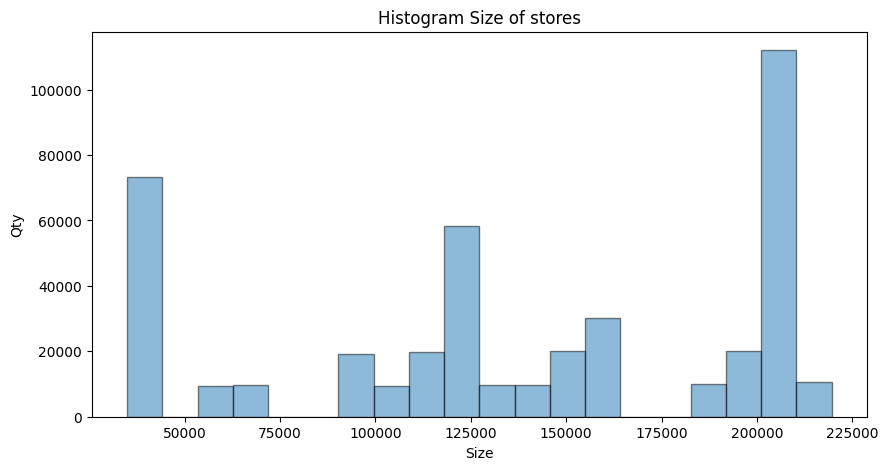

In [186]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data['Size'], edgecolor='black', bins=20, alpha=.5)

ax.set_title('Histogram Size of stores')
ax.set_xlabel('Size')
ax.set_ylabel('Qty')

Кажется, тут отлично просматривается возможная сегментация

Предлагаю сегментировать, назовем сегменты "дивизионы" 1, 2, 3

In [187]:
### от 175 000 div_1
### От 75 000 до 175 000 div_2
### до 75 000 div_3

## Сегментация магазинов

к результату 1 подтяну сегменты по диапазонам

In [188]:
bins = [0, 75000, 175000, 225000]
labels = ['div_3', 'div_2', 'div_1']

result_2 = data.copy()
result_2['Division'] = pd.cut(
    result_2['Size'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)
result_2

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,Week,Year,MarkDowns,Weight,Dept,Weekly_Sales,Type,Size,Month,Division
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,5,2010,NaN,1,1,24924.50,A,151315,2010-02-01,div_2
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,5,2010,NaN,1,2,50605.27,A,151315,2010-02-01,div_2
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,5,2010,NaN,1,3,13740.12,A,151315,2010-02-01,div_2
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,5,2010,NaN,1,4,39954.04,A,151315,2010-02-01,div_2
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,5,2010,NaN,1,5,32229.38,A,151315,2010-02-01,div_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,43,2012,5247.26,1,93,2487.80,B,118221,2012-10-01,div_2
421566,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,43,2012,5247.26,1,94,5203.31,B,118221,2012-10-01,div_2
421567,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,43,2012,5247.26,1,95,56017.47,B,118221,2012-10-01,div_2
421568,45,2012-10-26,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,...,43,2012,5247.26,1,97,6817.48,B,118221,2012-10-01,div_2


К датасету магазинов подтянем, посмотрим, как получилось по количеству магазинов в дивизионе

In [189]:
bins = [0, 75000, 175000, 225000]
labels = ['div_3', 'div_2', 'div_1']

stores_2 = stores.copy()
stores_2['Division'] = pd.cut(
    stores_2['Size'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)
stores_2

,Store,Type,Size,Division
0,1,A,151315,div_2
1,2,A,202307,div_1
2,3,B,37392,div_3
3,4,A,205863,div_1
4,5,B,34875,div_3
5,6,A,202505,div_1
6,7,B,70713,div_3
7,8,A,155078,div_2
8,9,B,125833,div_2
9,10,B,126512,div_2


In [190]:
stores_qty = stores_2['Division'].value_counts()
stores_qty

,count
Division,
div_2,18
div_1,15
div_3,12


Результат по количеству
- div_1	- 15
- div_2 -	18
- div_3	- 12

Отлично, это будут наши сегменты, которые будем сравнивать.

## Анализ временных рядов в разрезе наших дивизионов.
Построим визуализацию динамики недельных продаж по каждому дивизиону.

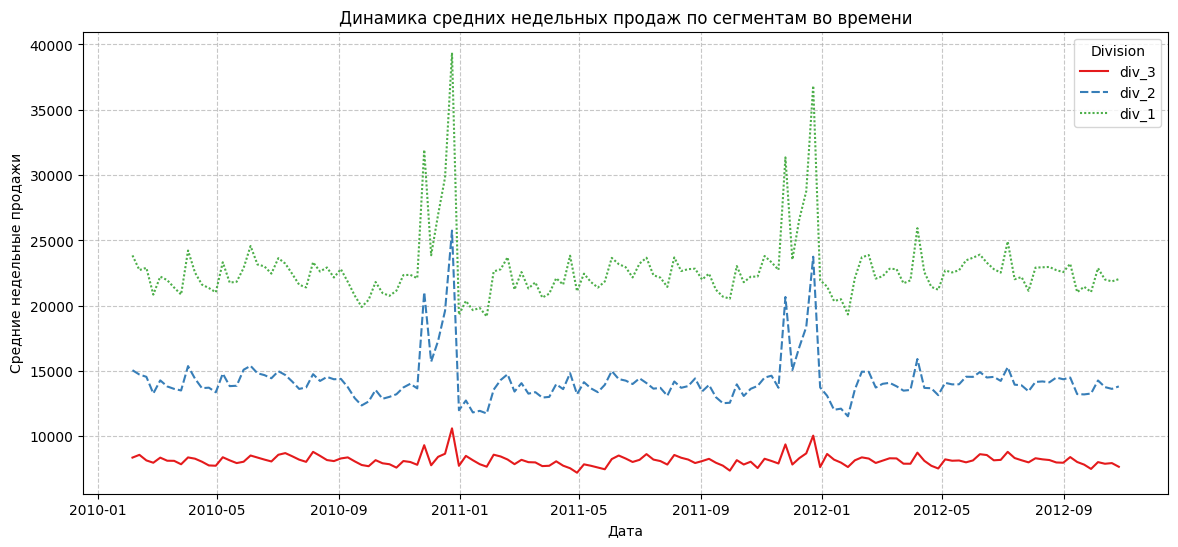

In [191]:
sales_trend = result_2.groupby(['Date', 'Division'])['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=sales_trend,
    x='Date',
    y='Weekly_Sales',
    style='Division',
    hue = "Division",
    palette='Set1',
    linewidth=1.5)
plt.title('Динамика средних недельных продаж по сегментам во времени')
plt.xlabel('Дата')
plt.ylabel('Средние недельные продажи')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [192]:
#чтобы не листать
result_2.sample(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,Week,Year,MarkDowns,Weight,Dept,Weekly_Sales,Type,Size,Month,Division
295804,31,2010-08-27,86.20,2.619,NaN,NaN,NaN,NaN,NaN,211.224176,...,34,2010,NaN,1,47,7.00,A,203750,2010-08-01,div_1
39713,4,2012-10-19,64.46,3.610,6313.84,NaN,15.05,2421.08,5885.12,131.149968,...,42,2012,NaN,1,94,76081.44,A,205863,2012-10-01,div_1
53180,6,2011-04-08,70.35,3.622,NaN,NaN,NaN,NaN,NaN,216.624433,...,14,2011,NaN,1,60,167.20,A,202505,2011-04-01,div_1
197031,20,2012-09-07,76.36,3.911,11783.56,-0.99,83.85,1938.40,3708.67,215.218957,...,36,2012,17513.49,5,81,37057.55,A,203742,2012-09-01,div_1
238828,25,2010-07-30,71.99,2.781,NaN,NaN,NaN,NaN,NaN,204.605272,...,30,2010,NaN,1,23,14097.84,B,128107,2010-07-01,div_2
273405,28,2011-11-04,59.77,3.828,NaN,NaN,NaN,NaN,NaN,129.805194,...,44,2011,NaN,1,4,32593.13,A,206302,2011-11-01,div_1
90810,10,2010-12-17,59.15,3.125,NaN,NaN,NaN,NaN,NaN,126.879484,...,50,2010,NaN,1,4,51071.91,B,126512,2010-12-01,div_2
100701,11,2010-11-19,58.63,2.771,NaN,NaN,NaN,NaN,NaN,215.207452,...,46,2010,NaN,1,1,14780.82,A,207499,2010-11-01,div_1
393978,42,2011-04-15,61.05,4.089,NaN,NaN,NaN,NaN,NaN,128.910733,...,15,2011,NaN,1,23,50.62,C,39690,2011-04-01,div_3
360809,38,2012-09-28,81.22,3.966,201.62,NaN,NaN,29.21,802.50,131.043000,...,39,2012,NaN,1,6,14.82,C,39690,2012-09-01,div_3


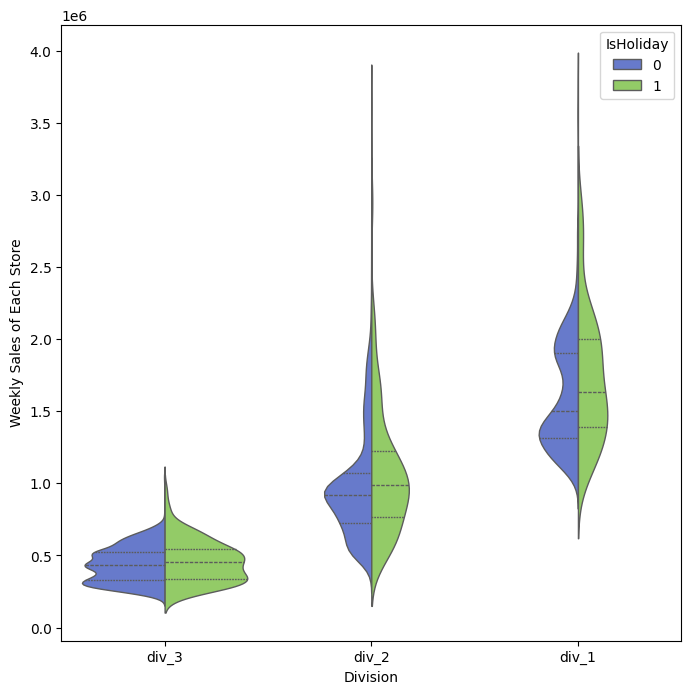

In [193]:
tmp = result_2.groupby(['Store', 'Date'])['Weekly_Sales'].sum().reset_index()  # weekly total sales of stores
tmp = tmp.merge(result_2[['Store','Division']].drop_duplicates(), on='Store', how='left')
tmp = tmp.merge(result_2[['Date', 'IsHoliday']].drop_duplicates(), on='Date', how='left')

plt.figure(figsize=(8, 8))
sns.violinplot(
    x='Division',
    y='Weekly_Sales',
    hue='IsHoliday',
    data=tmp,
    inner='quart',
    split=True,
    linewidth=1,
    palette={True: sns.color_palette('hls', 8)[2], False: sns.color_palette('hls', 8)[5]}
)
plt.ylabel('Weekly Sales of Each Store')
plt.show()

## Анализ сезонных и праздничных эффектов.

#### Сравнение недельных продаж

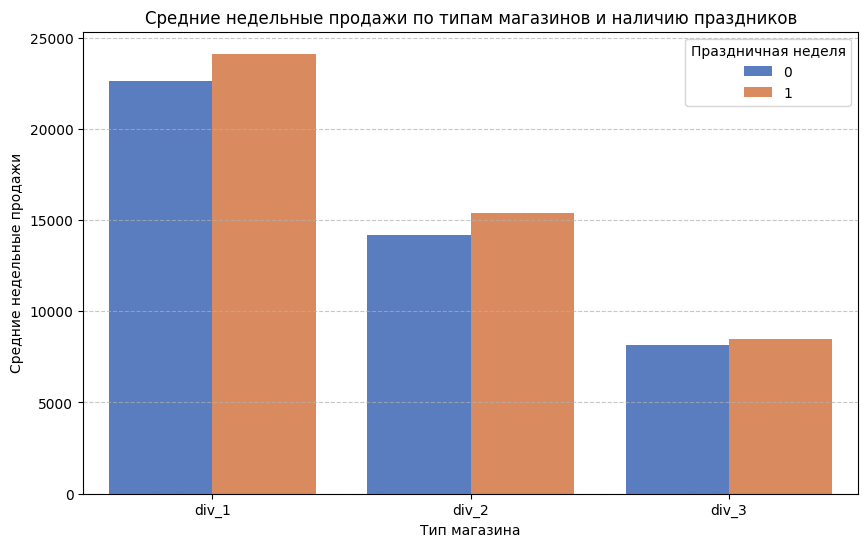

In [194]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=result_2,
    x='Division',
    y='Weekly_Sales',
    hue='IsHoliday',
    palette='muted',
    errorbar=None,
    order=['div_1', 'div_2', 'div_3']
)
plt.title('Средние недельные продажи по типам магазинов и наличию праздников')
plt.xlabel('Тип магазина')
plt.ylabel('Средние недельные продажи')
plt.legend(title='Праздничная неделя')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

#### p-value по тесту Левена

In [195]:
# p-value

# ряды недельных продаж для каждого типа
sales_a = result_2[result_2['Division'] == 'div_1']['Weekly_Sales'].dropna()
sales_b = result_2[result_2['Division'] == 'div_2']['Weekly_Sales'].dropna()
sales_c = result_2[result_2['Division'] == 'div_3']['Weekly_Sales'].dropna()


p_value_levene = stats.levene(sales_a, sales_b, sales_c)
print(f'{p_value_levene.pvalue:.3f}')

0.000


Значение p-value = 0.000

Отлично, теперь можем точно сказать, что в сравнении дисперсий продаж между дивизионами есть разница, и магазины разного размера ведут себя по-разному с точки зрения стабильности выручки.


Теперь нам нужно проверить, что причина именно низкая волатильность продаж в крупных магазинах. Проводим дальнейший анализ.

В данном случае нам не подойдет проверка  обычной дисперсии, будем использовать метрику **коэффициент вариации (CV)** так как он посчитает относительный разброс.

# Проверка гипотезы

#### Расчет средних продаж, ст. отклонения и коэффициента вариации

 будем использовать метрику **коэффициент вариации (CV)** так как он посчитает относительный разброс.

In [196]:
cv_df = result_2.groupby('Division')['Weekly_Sales'].agg(
    Mean_Sales='mean',
    Std_Sales='std',
    Count='count'
).reset_index()

# коэффициент вариации, % : (std / mean) * 100

cv_df['Coefficient_Of_Variation'] = (cv_df['Std_Sales'] / cv_df['Mean_Sales']) * 100

print("коэфф. вариации по типам магазинов")
print(cv_df[['Division', 'Mean_Sales', 'Std_Sales', 'Coefficient_Of_Variation']])

коэфф. вариации по типам магазинов
  Division    Mean_Sales     Std_Sales  Coefficient_Of_Variation
0    div_3   8157.987260  13658.942139                167.430295
1    div_2  14242.689736  18886.637225                132.605832
2    div_1  22739.383284  28518.907461                125.416363


Визуализируем наш результат для наглядности

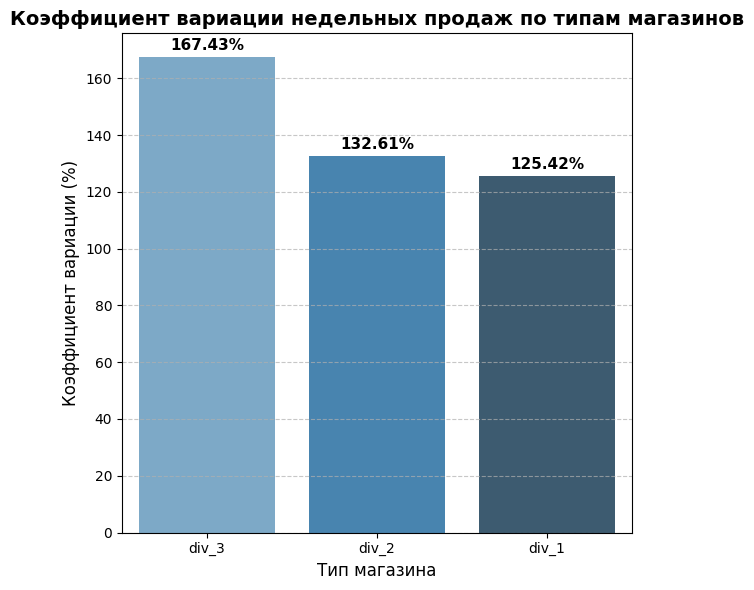

In [197]:
plt.figure(figsize=(6, 6))
bars = sns.barplot(
    data=cv_df,
    x='Division',
    y='Coefficient_Of_Variation',
    palette='Blues_d'
)

plt.title('Коэффициент вариации недельных продаж по типам магазинов', fontsize=14, fontweight='bold')
plt.xlabel('Тип магазина', fontsize=12)
plt.ylabel('Коэффициент вариации (%)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)


for p in bars.patches:
    height = p.get_height()
    if not np.isnan(height):
        bars.annotate(
            f'{height:.2f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

Отлично, мы видим четкую разницу в коэффициентах вариации у каждого дивизиона.  

`Трактовка значения CV : Чем меньше значение CV, тем большую устойчивость демонстрирует дивизион в относительном выражении.`

### Итог по гипотезе 1. Мы сравнили 3 группы и можем сказать: у первого дивизиона коэффициент вариации ниже других, следовательно, мы **подтверждаем гипотезу**.

`"Чем больше магазин по площади - тем он устойчивее к влияниям внешних факторов."`

Возможные причины устойчивости больших магазинов:
- Крупные магазины имеют более диверсифицированный ассортимент, если клиент не нашел желаемый товар, широкая матрица предложит альтернативу, клиент не уйдет ни с чем.
- Большой магазин это больше площадь, которую обойдет покупатель, а длительное пребывание в магазине увеличивает средний чек.
- У крупных магазинов больше складские мощности, что помогает стабильно поддерживать товарный запас на полках, следовательно, в таком магазине упущенные продажи меньше.
- В большом магазине можно сделать широкий ценовой диапазон товаров. Это поможет и человеку в трудной финансовой ситуации купить, все что требуется, по низким ценам. И в обратной ситуации, ассортимент удовлетворит желание пошиковать, купив дорогие товары.


### Рекомендации для стратегии по развитию торговой сети:

- Акцент на открытии крупных торговых точек.
- Расширение существующих магазинов.
- Оптимизация планировки для увеличения времени пребывания покупателей в торговом зале.
- Формирование сбалансированного ассортимента, чтобы поддерживать клиента с любой покупательской способностью
- Фокус на создание более универсального списка категорий, сейчас не все отделы, приносящие крупную маржу, присутствуют во всех магазинах.


# Пройденные шаги:

### Подготовка и сегментация:

*   Используется колонка Size исходной таблицы stores.
*   Применяется метод биннинга (pd.cut) для разделения всех магазинов на 3 искусственных сегмента — дивизиона: div_1 (крупные, свыше 175 тыс. кв. ед.), div_2 (средние, 75–175 тыс.) и div_3 (малые, до 75 тыс.).


### Мерж таблиц:
Объединяются датасеты features, sales и stores по ключам Store и Date, формируя единую витрину данных result_2.

### EDA и динамика:
* Рассчитываются средние недельные продажи во времени в разрезе созданных дивизионов (sales_trend).
* Строятся линейные тренды для оценки реакции дивизионов на макропоказатели.

### Расчет метрик волатильности:
* Вычисляются среднее, стандартное отклонение и коэффициент вариации для каждого дивизиона.

### Статистическая проверка (p-value):

Применяется тест Левена (stats.levene) для проверки гипотезы о равенстве дисперсий недельных продаж между дивизионами, чтобы подтвердить статистическую значимость различий в стабильности.


И мем 🙂


дивизион побольше, поменьше, маленький вообще жесть

![дивизион побольше, поменьше, маленький вообще жесть](https://habrastorage.org/r/w1560/getpro/habr/upload_files/3a2/b50/8e9/3a2b508e9dbd7c8bb2474cc65f3e607d.png)